# ΣΔ Decimator — Analysis Notebook

Stage 2 of the Trouper DSP chain. Converts each SX1257 1-bit complex ΣΔ bitstream
(32 MS/s) into signed 8-bit IQ samples for the on-chip receive path.

**Deployed configuration:** half-band chain, fixed **R=64** (`sd_decimator_poly.v`):
CIC-3 R=16 → HB1 ÷2 → HB2 ÷2 → int8 IQ at **500 kS/s**, for both 125 kHz and
250 kHz LoRa bandwidths. Bandwidth selects only `sample_shift` (oversampling)
via register `0x0A` (`BW_CFG.bw_sel`), not the decimation ratio.

This replaces the earlier CIC-only R=128 chain, which put the 250 kHz chirp
band edge at Nyquist (−11.8 dB droop). Splitting the same total R=64 into a
short CIC-3 R=16 front end plus two near-brickwall half-bands holds the
CIC-stage droop at that same edge to about **−0.17 dB**; the full CIC+HB1+HB2
cascade adds a further ~0.2 dB of half-band roll-off, for a combined 250 kHz
edge droop of roughly **−0.4 dB** — still far better than the old −11.8 dB.
The old architecture is no longer deployed and should not be used as a
reference point.

**Reference:** `planning/decimator-hb-migration-impact-plan.md` (Gates 0–12),
`planning/decimator-hb-redesign.md`, `planning/decimator-hb-area-reduction.md`

In [12]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))

import numpy as np
import matplotlib.pyplot as plt

from sim.models.decimator import (
    SigmaDeltaDecimator, decimation_ratio, sample_shift_for_bw,
    FS_ADC, FS_OUT, DECIMATION_RATIO, SUPPORTED_BW,
)
from sim.models.lora import modulate

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


def modulate_oversampled(b: int, sf: int, os: int) -> np.ndarray:
    """
    Correctly band-limited LoRa chirp, oversampled by `os` at the same physical
    BW and symbol duration as the native (Nyquist-rate) chirp.

    `modulate(b, M)` always sweeps the FULL normalised digital bandwidth
    (0..1 cycle/sample) over its `M` samples, no matter what `M` is. Calling
    it directly with `M = 2**sf * os` (the oversampled sample count) silently
    produces a chirp spanning the full sample-rate Nyquist band instead of the
    intended `BW = fs_native` band -- e.g. for a 125 kHz BW symbol oversampled
    4x at 500 kS/s, `modulate(0, 2**sf*4)` sweeps +/-250 kHz, not +/-62.5 kHz.

    This substitutes `n -> n/os` into the same phase law so the oversampled
    signal is the same physical chirp (same BW, same duration), just sampled
    `os` times faster. Reduces to `modulate(b, 2**sf)` at os=1.
    """
    m_native = 2 ** sf
    n = np.arange(m_native * os)
    phase = np.pi * (2 * b * n / os + n ** 2 / os ** 2) / m_native
    return np.exp(1j * phase)
print(f'FS_ADC  = {FS_ADC/1e6:.0f} MS/s')
print(f'FS_OUT  = {FS_OUT/1e3:.0f} kS/s (fixed)')
print(f'R       = {DECIMATION_RATIO} (fixed for all supported BWs)')
print(f'Supported LoRa BWs: {[bw/1e3 for bw in SUPPORTED_BW]} kHz')

FS_ADC  = 32 MS/s
FS_OUT  = 500 kS/s (fixed)
R       = 64 (fixed for all supported BWs)
Supported LoRa BWs: [125.0, 250.0] kHz


---
## 1  CIC + Half-Band Cascade Frequency Response

The decimator is a three-stage cascade:

$$H(z) = H_{\text{CIC-3}}(z; R=16) \cdot H_{\text{HB1}}(z) \cdot H_{\text{HB2}}(z)$$

- **CIC-3, R=16**: 32 MS/s → 2 MS/s, transfer function $\left[\frac{1-z^{-16}}{1-z^{-1}}\right]^3$ (normalised by $16^3$)
- **HB1**: 2 MS/s → 1 MS/s, 11-tap half-band FIR, coefficients `[19,0,-73,0,312,512,312,0,-73,0,19]/1024`
- **HB2**: 1 MS/s → 500 kS/s, 15-tap half-band FIR, coefficients `[-27,0,45,0,-96,0,321,512,321,0,-96,0,45,0,-27]/1024`

Coefficients match `sd_decimator_poly.v` (`sd_decimator_poly_hb1_mac` / `_hb2_mac`).
Compared to the retired R=128 CIC-only chain, using a short R=16 CIC front
end holds the CIC-stage droop at the 250 kHz chirp edge to about −0.17 dB
(vs −11.8 dB for a full R=128 CIC at the same relative edge); the two
half-bands then add their own small roll-off on top, for a combined cascade
droop of roughly −0.4 dB at that edge.

I and Q are each decimated through independent instances of this same
real-coefficient chain (no cross-terms), so the magnitude response is even
in frequency: `|H(f)| = |H(-f)|`. The plot below sweeps the complex (IQ)
baseband range **−fs_out to +fs_out** (wider than the ±fs_out/2 = ±250 kHz
Nyquist band, marked with red dash-dot lines) to show the roll-off past
Nyquist, with LoRa chirp edges marked on both sides since a chirp spans
`±BW/2` around DC.

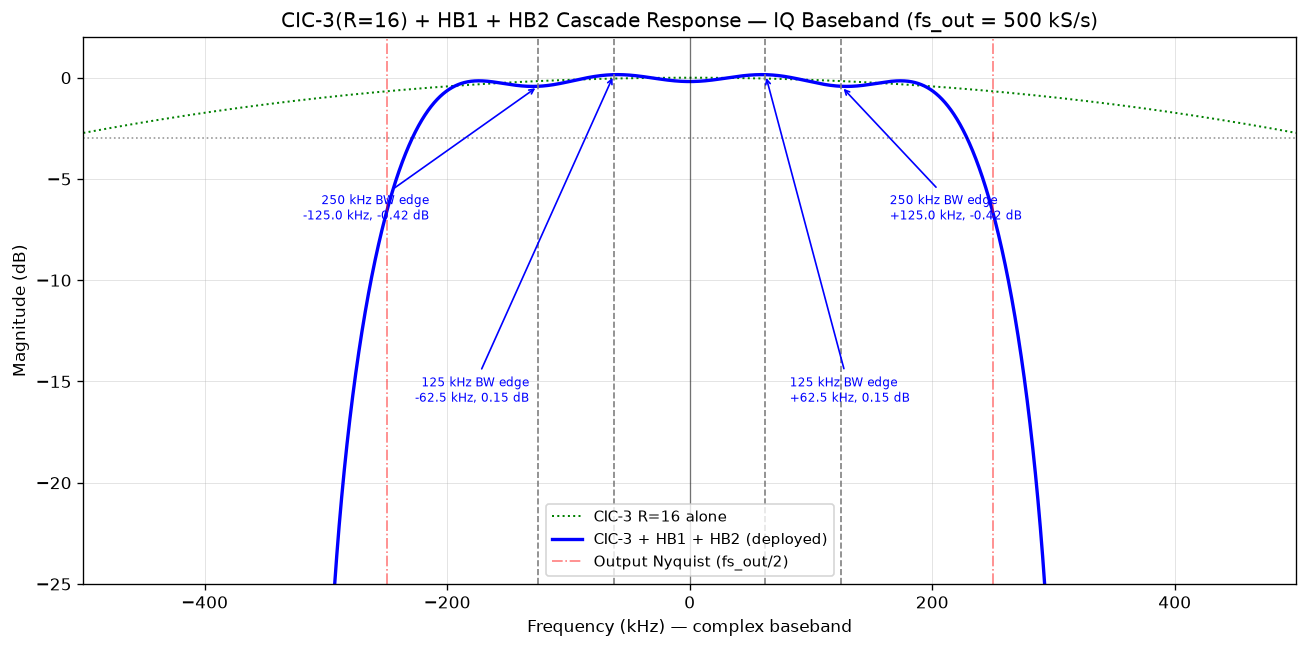

250 kHz BW chirp edge (125.0 kHz): -0.42 dB droop
125 kHz BW chirp edge (62.5 kHz): 0.15 dB droop
Saved: sim/plots/sd_decimator_response.png


In [13]:
def cic_response_db(R: int, N: int, fs_in: float, freqs_hz: np.ndarray) -> np.ndarray:
    """Normalised CIC magnitude response (dB) at fs_in, evaluated at freqs_hz."""
    f_norm = np.maximum(np.abs(freqs_hz) / fs_in, 1e-12)
    h = np.abs(np.sin(np.pi * R * f_norm) / (R * np.sin(np.pi * f_norm))) ** N
    return 20 * np.log10(np.maximum(h, 1e-12))


def fir_response_db(coeffs: np.ndarray, fs: float, freqs_hz: np.ndarray) -> np.ndarray:
    """FIR magnitude response (dB) at fs, evaluated at freqs_hz."""
    n = np.arange(len(coeffs))
    H = np.array([
        np.sum(coeffs * np.exp(-2j * np.pi * f * n / fs))
        for f in freqs_hz
    ])
    return 20 * np.log10(np.maximum(np.abs(H), 1e-12))


HB1_COEFFS = np.array([19, 0, -73, 0, 312, 512, 312, 0, -73, 0, 19]) / 1024.0
HB2_COEFFS = np.array([-27, 0, 45, 0, -96, 0, 321, 512, 321, 0, -96, 0, 45, 0, -27]) / 1024.0

# Complex (IQ) baseband: I and Q are each real-coefficient filters, so the
# response is even in frequency. Evaluate over -fs_out .. +fs_out (wider than
# the ±fs_out/2 Nyquist band) so the passband-to-stopband roll-off is visible.
freqs = np.linspace(-FS_OUT, FS_OUT, 8192)

h_cic = cic_response_db(R=16, N=3, fs_in=FS_ADC, freqs_hz=freqs)
h_hb1 = fir_response_db(HB1_COEFFS, fs=2e6, freqs_hz=freqs)
h_hb2 = fir_response_db(HB2_COEFFS, fs=1e6, freqs_hz=freqs)
h_total = h_cic + h_hb1 + h_hb2

edges = {250e3: 125e3, 125e3: 62.5e3}  # BW -> chirp band edge frequency (one-sided)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(freqs / 1e3, h_cic,   'g:',  lw=1.2, label='CIC-3 R=16 alone')
ax.plot(freqs / 1e3, h_total, 'b-',  lw=2,   label='CIC-3 + HB1 + HB2 (deployed)')
ax.axhline(-3, color='k', ls=':', lw=1, alpha=0.4)
ax.axvline(0, color='k', lw=0.8, alpha=0.5)
ax.axvline(FS_OUT / 2e3, color='r', ls='-.', lw=1, alpha=0.5, label='Output Nyquist (fs_out/2)')
ax.axvline(-FS_OUT / 2e3, color='r', ls='-.', lw=1, alpha=0.5)

# 4 markers (bw, sign) placed with distinct (dx, y) offsets so labels don't
# collide even though the two BW edges per side are only 62.5 kHz apart.
markers = [(250e3, -1, -90, -7), (125e3, -1, -70, -16), (125e3, +1, 20, -16), (250e3, +1, 40, -7)]
for bw, sign, dx, y_off in markers:
    edge = edges[bw]
    f_edge = sign * edge
    idx = np.argmin(np.abs(freqs - f_edge))
    ax.axvline(f_edge / 1e3, color='gray', ls='--', lw=1)
    ax.annotate(f'{bw/1e3:.0f} kHz BW edge\n{f_edge/1e3:+.1f} kHz, {h_total[idx]:.2f} dB',
                xy=(f_edge / 1e3, h_total[idx]), xytext=(f_edge / 1e3 + dx, y_off),
                arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=7,
                ha='left' if dx >= 0 else 'right')

ax.set_xlim(-FS_OUT / 1e3, FS_OUT / 1e3)
ax.set_ylim(-25, 2)
ax.set_xlabel('Frequency (kHz) — complex baseband')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('CIC-3(R=16) + HB1 + HB2 Cascade Response — IQ Baseband (fs_out = 500 kS/s)')
ax.legend(fontsize=9, loc='lower center')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/sd_decimator_response.png', bbox_inches='tight')
plt.show()

for bw, edge in edges.items():
    idx = np.argmin(np.abs(freqs - edge))
    print(f'{bw/1e3:.0f} kHz BW chirp edge ({edge/1e3:.1f} kHz): {h_total[idx]:.2f} dB droop')
print('Saved: sim/plots/sd_decimator_response.png')

---
## 2  SQNR Measurement

SQNR is measured by feeding a 1st-order ΣΔ-modulated tone at **0.4×Nyquist**
(relative to the 500 kS/s output) through the full `SigmaDeltaDecimator` model
and fitting a sine to the output.

**RTL benchmark** (`planning/decimator-hb-migration-impact-plan.md`, Gate 1,
SGE jobs 2081/2082): shared and parallel RTL matched 191 random packed
outputs bit-exactly; analysis found about **42 dB** worst-tested SQNR and
about **−0.5 dB** gain error at 125 kHz BW. Gate 1 accept threshold is
SQNR ≥ 40 dB and gain error ≤ 0.5 dB. A full RTL spectral sweep is still
pending (Gate status: Partial).

Unlike the old floating-point CIC-only Python model, `_cic_r16_int8`,
`_hb1`, and `_hb2` in `sim/models/decimator.py` are **integer, RTL-exact**
implementations (same saturating arithmetic as `sd_decimator_poly.v`), so
the Python SQNR figures below should track RTL closely rather than being a
rough floating-point approximation.

In [14]:
def sigma_delta_1st_order(x: np.ndarray) -> np.ndarray:
    """1st-order ΣΔ modulator. Input must be |x| < 1 for stability. Returns ±1."""
    out = np.empty_like(x)
    e = 0.0
    for i, xi in enumerate(x):
        u = xi + e
        q = 1.0 if u >= 0.0 else -1.0
        e = u - q
        out[i] = q
    return out


def measure_sqnr(bw_hz: float, n_periods: int = 500, amp: float = 0.9):
    """Feed a tone at 0.4×Nyquist through ΣΔ -> decimator, fit a sine, return SQNR in dB."""
    dec = SigmaDeltaDecimator(bw_hz=bw_hz)
    fs_out = dec.fs_out
    f_tone = 0.4 * dec.nyquist_hz

    n_out = n_periods * int(round(fs_out / f_tone))
    n_in = n_out * DECIMATION_RATIO
    t_in = np.arange(n_in) / FS_ADC

    tone = amp * np.sin(2 * np.pi * f_tone * t_in)
    bits = sigma_delta_1st_order(tone) + 0j  # real tone only; Q stays zero

    out = dec.process_int8(bits).real

    skip = 200  # discard CIC+HB cascade settling transient
    y = out[skip:]
    n = np.arange(len(y))

    omega = 2 * np.pi * f_tone / fs_out
    C = np.column_stack([np.cos(omega * n), np.sin(omega * n)])
    coeffs, _, _, _ = np.linalg.lstsq(C, y, rcond=None)
    fitted = C @ coeffs
    signal_amp = np.sqrt(coeffs[0] ** 2 + coeffs[1] ** 2)
    noise_rms = float(np.std(y - fitted))

    sqnr = 20 * np.log10(signal_amp / noise_rms) if noise_rms > 0 else float('inf')
    return sqnr


rtl_sqnr_worst = 42.0  # Gate 1, SGE jobs 2081/2082 (worst tested, full sweep pending)

print(f'{"BW":>8}  {"sample_shift":>12}  {"Python SQNR":>12}  {"RTL (worst, Gate 1)":>20}  {"Pass (>=40dB)":>13}')
print('-' * 76)
for bw in SUPPORTED_BW:
    sqnr_py = measure_sqnr(bw)
    passed = '✓' if sqnr_py >= 40 else '✗'
    print(f'{bw/1e3:>6.0f}kHz  {sample_shift_for_bw(bw):>12d}  '
          f'{sqnr_py:>10.1f} dB  {rtl_sqnr_worst:>18.1f} dB  {passed:>13}')

print()
print('RTL is authoritative; Gate 1 full spectral sweep is still pending')
print('(planning/decimator-hb-migration-impact-plan.md, Gate 1 status: Partial).')

      BW  sample_shift   Python SQNR   RTL (worst, Gate 1)  Pass (>=40dB)
----------------------------------------------------------------------------
   125kHz             2        51.6 dB                42.0 dB              ✓
   250kHz             1        51.6 dB                42.0 dB              ✓

RTL is authoritative; Gate 1 full spectral sweep is still pending
(planning/decimator-hb-migration-impact-plan.md, Gate 1 status: Partial).


---
## 3  Noise Floor Spectra

Output spectra for both supported bandwidths, at the same 0.4×Nyquist test
tone used for the SQNR measurement above. Both configurations use the same
fixed R=64 chain; only `sample_shift` differs, which does not affect this
spectrum since it only changes symbol-domain windowing, not the decimator
itself.

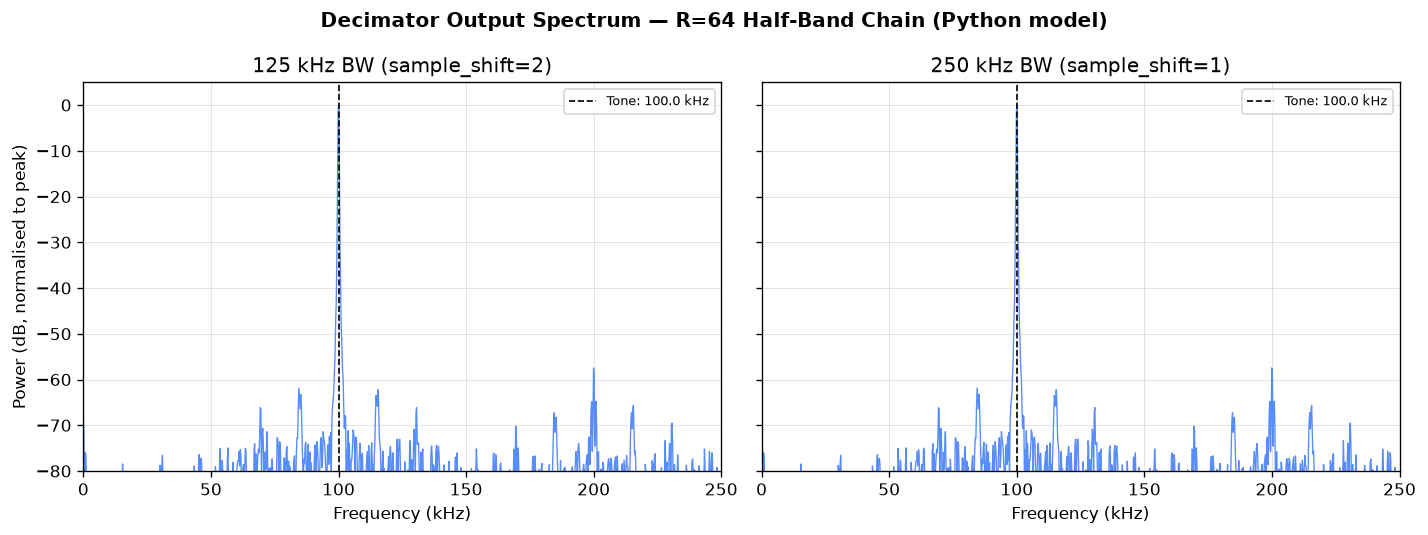

Saved: sim/plots/sd_decimator_spectra.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, bw in zip(axes, SUPPORTED_BW):
    dec = SigmaDeltaDecimator(bw_hz=bw)
    fs_out = dec.fs_out
    f_tone = 0.4 * dec.nyquist_hz
    n_out = 2048
    n_in = n_out * DECIMATION_RATIO
    t_in = np.arange(n_in) / FS_ADC
    tone = 0.9 * np.sin(2 * np.pi * f_tone * t_in)
    bits = sigma_delta_1st_order(tone) + 0j
    out = dec.process_int8(bits).real[-n_out:]

    N_fft = len(out)
    window = np.hanning(N_fft)
    S = np.abs(np.fft.rfft(out * window)) ** 2
    S_db = 10 * np.log10(S / S.max() + 1e-12)
    freqs = np.fft.rfftfreq(N_fft) * fs_out / 1e3  # kHz

    ax.plot(freqs, S_db, lw=0.8)
    ax.axvline(f_tone / 1e3, color='k', ls='--', lw=1, label=f'Tone: {f_tone/1e3:.1f} kHz')
    ax.set_xlim(0, fs_out / 2e3)
    ax.set_ylim(-80, 5)
    ax.set_xlabel('Frequency (kHz)')
    ax.set_title(f'{bw/1e3:.0f} kHz BW (sample_shift={dec.sample_shift})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

axes[0].set_ylabel('Power (dB, normalised to peak)')
fig.suptitle('Decimator Output Spectrum — R=64 Half-Band Chain (Python model)', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/sd_decimator_spectra.png', bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_decimator_spectra.png')

---
## 4  Supported Operating Modes

The decimator ratio is **fixed at R=64** for every supported configuration —
there is no per-BW ratio register any more. Bandwidth selects `sample_shift`
via register `0x0A` (`BW_CFG`, `bw_sel` bit[0]; 0 = 250 kHz, 1 = 125 kHz),
which affects only the symbol-domain window `M = 1 << (SF + sample_shift)`
consumed by the SC detector, training accumulator, packet-control FSM, and
PSRAM delay logic — not the decimator itself.

For 125 kHz BW, the chain is intentionally **4× oversampled** relative to the
LoRa symbol rate (2× for 250 kHz BW). 1 MS/s output is explicitly **out of
scope** — the PSRAM timing budget does not support it.

In [16]:
hdr = f'{"LoRa BW":>10}  {"R":>5}  {"fs_out":>10}  {"sample_shift":>13}  {"Oversampling":>13}'
print(hdr)
print('-' * len(hdr))
for bw in SUPPORTED_BW:
    R = decimation_ratio(bw)
    shift = sample_shift_for_bw(bw)
    print(f'{bw/1e3:>8.0f}kHz  {R:>5d}  {FS_OUT/1e3:>8.0f}kS/s  {shift:>13d}  {2**shift:>11d}x')

print()
print('R=64 is fixed for all supported BWs; BW_CFG.bw_sel (reg 0x0A) selects sample_shift only.')
print('1 MS/s output is out of scope (PSRAM timing budget exceeded).')

   LoRa BW      R      fs_out   sample_shift   Oversampling
-----------------------------------------------------------
     125kHz     64       500kS/s              2            4x
     250kHz     64       500kS/s              1            2x

R=64 is fixed for all supported BWs; BW_CFG.bw_sel (reg 0x0A) selects sample_shift only.
1 MS/s output is out of scope (PSRAM timing budget exceeded).


---
## 5  Samples per Symbol

The number of samples per LoRa symbol is `M = 1 << (SF + sample_shift)`:
- **250 kHz BW** (`sample_shift=1`): M = 2·2^SF (2× oversampled)
- **125 kHz BW** (`sample_shift=2`): M = 4·2^SF (4× oversampled)

This integer-M property is essential for the SC detector (Schmidl-Cox
requires exactly one symbol window = M samples) and is the single
authoritative value shared by SC, PSRAM delay, training accumulator, and
packet-control timing (Gate 4).

In [17]:
dec = SigmaDeltaDecimator(bw_hz=250e3)  # R and fs_out are BW-independent

print('R=64, fs_out=500 kS/s — samples per symbol M = 1 << (SF + sample_shift)')
print(f'{"SF":>4}  {"250kHz BW":>10}  {"125kHz BW":>10}  {"2*2^SF":>8}  {"4*2^SF":>8}')
print('-' * 50)
for sf in range(7, 13):
    m_250 = dec.samples_per_symbol(sf, bw_hz=250e3)
    m_125 = dec.samples_per_symbol(sf, bw_hz=125e3)
    assert m_250 == 2 * 2**sf, f'SF{sf} 250kHz: M={m_250} != 2*2^SF={2*2**sf}'
    assert m_125 == 4 * 2**sf, f'SF{sf} 125kHz: M={m_125} != 4*2^SF={4*2**sf}'
    print(f'{sf:>4}  {m_250:>10d}  {m_125:>10d}  {2*2**sf:>8d}  {4*2**sf:>8d}')

# Training window sanity check against Gate 6 (8*M, max at SF12/125kHz)
m_max = dec.samples_per_symbol(12, bw_hz=125e3)
n_acc_max = 8 * m_max
print()
print(f'SF12/125kHz: M={m_max}, training window 8*M={n_acc_max} (Gate 6 max: 131072)')
assert n_acc_max == 131072

print()
print('PASS  M = 1 << (SF + sample_shift) for all SF7-SF12, both BWs')

R=64, fs_out=500 kS/s — samples per symbol M = 1 << (SF + sample_shift)
  SF   250kHz BW   125kHz BW    2*2^SF    4*2^SF
--------------------------------------------------
   7         256         512       256       512
   8         512        1024       512      1024
   9        1024        2048      1024      2048
  10        2048        4096      2048      4096
  11        4096        8192      4096      8192
  12        8192       16384      8192     16384

SF12/125kHz: M=16384, training window 8*M=131072 (Gate 6 max: 131072)

PASS  M = 1 << (SF + sample_shift) for all SF7-SF12, both BWs


---
## 6  Multi-Branch Coherence

The training accumulator and MRC combiner require all four receive branches
to be sample-aligned. Any persistent offset between decimator instances
would silently corrupt the cross-correlation.

**Required conditions (verified here for the Python model; must also hold in RTL):**
1. Identical inputs → identical outputs
2. All branches produce the same number of output samples (coincident `iq_valid`)

Output length per branch: [256, 256, 256, 256]
All branches identical:   True
All branches same length: True
PASS  Multi-branch coherence: identical inputs -> identical aligned outputs


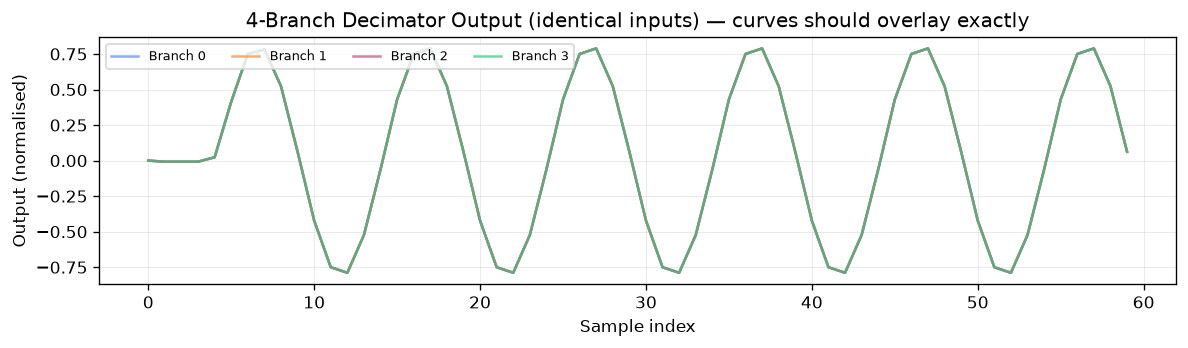

In [18]:
rng = np.random.default_rng(42)
NR = 4
BW = 250e3
N_in = DECIMATION_RATIO * 256

# Shared ΣΔ bitstream (same signal, same phase — simulates same SX1257 front-end path)
tone_freq = 0.2 * FS_ADC / DECIMATION_RATIO / 2
t = np.arange(N_in) / FS_ADC
base_signal = 0.8 * np.sin(2 * np.pi * tone_freq * t)

decimators = [SigmaDeltaDecimator(bw_hz=BW) for _ in range(NR)]
outputs = []
for j in range(NR):
    bits_j = sigma_delta_1st_order(base_signal) + 0j
    out_j = decimators[j].process(bits_j)
    outputs.append(out_j)

# Check all outputs match branch 0
all_same = all(np.allclose(outputs[j], outputs[0]) for j in range(1, NR))
same_length = all(len(outputs[j]) == len(outputs[0]) for j in range(1, NR))

print(f'Output length per branch: {[len(o) for o in outputs]}')
print(f'All branches identical:   {all_same}')
print(f'All branches same length: {same_length}')
assert all_same, 'Branches differ — coherence FAIL'
assert same_length, 'Branch lengths differ — coherence FAIL'
print('PASS  Multi-branch coherence: identical inputs -> identical aligned outputs')

fig, ax = plt.subplots(figsize=(10, 3))
n_show = 60
for j in range(NR):
    ax.plot(outputs[j][:n_show].real, lw=1.5, alpha=0.7, label=f'Branch {j}')
ax.set_xlabel('Sample index')
ax.set_ylabel('Output (normalised)')
ax.set_title('4-Branch Decimator Output (identical inputs) — curves should overlay exactly')
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7  DC Response and Saturation

A constant `+1` bitstream (maximum positive DC) should give an output that
settles to a stable, near-full-scale value and stays there (no oscillation,
no drift). The CIC + HB cascade's fixed-point coefficients do not sum to an
exact power of two, so the settled value is a specific fixed-point constant
rather than exactly ±127/128 — this is expected integer-arithmetic behaviour,
not a bug (RTL-exact per `sd_decimator_poly.v`). The CIC + HB cascade also
takes more output samples to settle than the old CIC-only chain (three
stages of group delay instead of one).

PASS  DC +1: settled to constant 0.9688 within 20 output samples
PASS  DC -1: settled to constant -0.9766 within 20 output samples


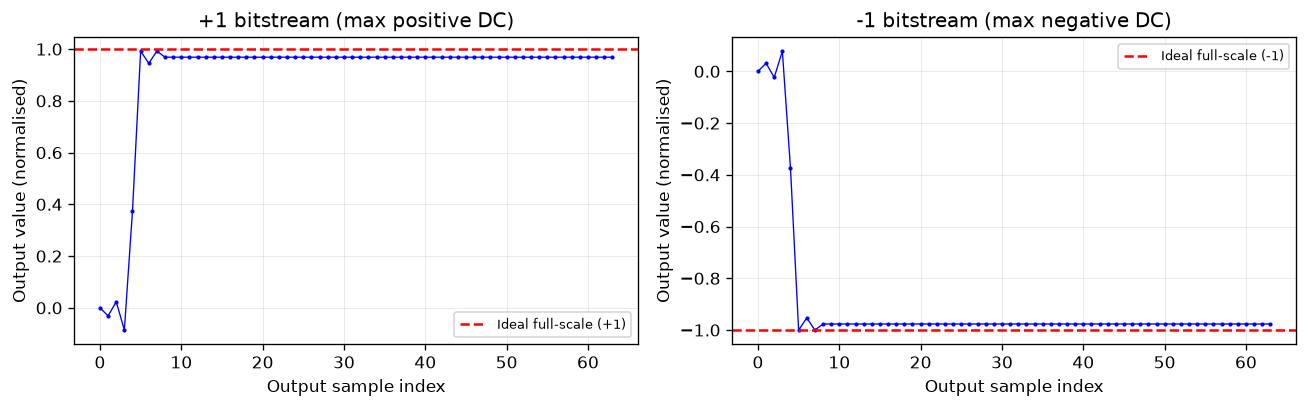

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, polarity, label in [
    (axes[0], +1.0, '+1 bitstream (max positive DC)'),
    (axes[1], -1.0, '-1 bitstream (max negative DC)'),
]:
    N_in = DECIMATION_RATIO * 64
    bits = np.full(N_in, polarity, dtype=np.complex128)
    dec = SigmaDeltaDecimator(bw_hz=250e3)
    out = dec.process(bits).real

    ax.plot(out, 'b.-', ms=3, lw=0.8)
    ax.axhline(polarity, color='r', ls='--', lw=1.5, label=f'Ideal full-scale ({polarity:+.0f})')
    ax.set_xlabel('Output sample index')
    ax.set_ylabel('Output value (normalised)')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    steady = out[20:]  # skip cascade settling transient
    settled_value = steady[-1]
    assert np.allclose(steady, settled_value, atol=1e-9), \
        f'DC output has not settled: steady segment is not constant ({steady[:5]}...)'
    assert abs(settled_value) > 0.9, f'DC steady-state too far from full scale: {settled_value:.4f}'
    print(f'PASS  DC {polarity:+.0f}: settled to constant {settled_value:.4f} within 20 output samples')

plt.tight_layout()
plt.show()

---
## 8  LoRa Chirp Loopback

Feed a LoRa upchirp symbol through a 1st-order ΣΔ ADC and the half-band
decimator, for both supported bandwidths. The output should closely
reproduce the reference chirp — the cascade keeps passband droop to roughly
−0.4 dB at the 250 kHz chirp edge (Section 1), so no separate droop-equalizer
FIR stage is needed (unlike the retired CIC-only chain).

The reference chirp uses `modulate_oversampled()` (defined in the imports
cell), not `modulate(0, M)` directly — the latter always sweeps the full
sample-rate Nyquist band regardless of `M`, which would silently generate a
chirp spanning ±250 kHz even for the 125 kHz BW case instead of the correct
±62.5 kHz.

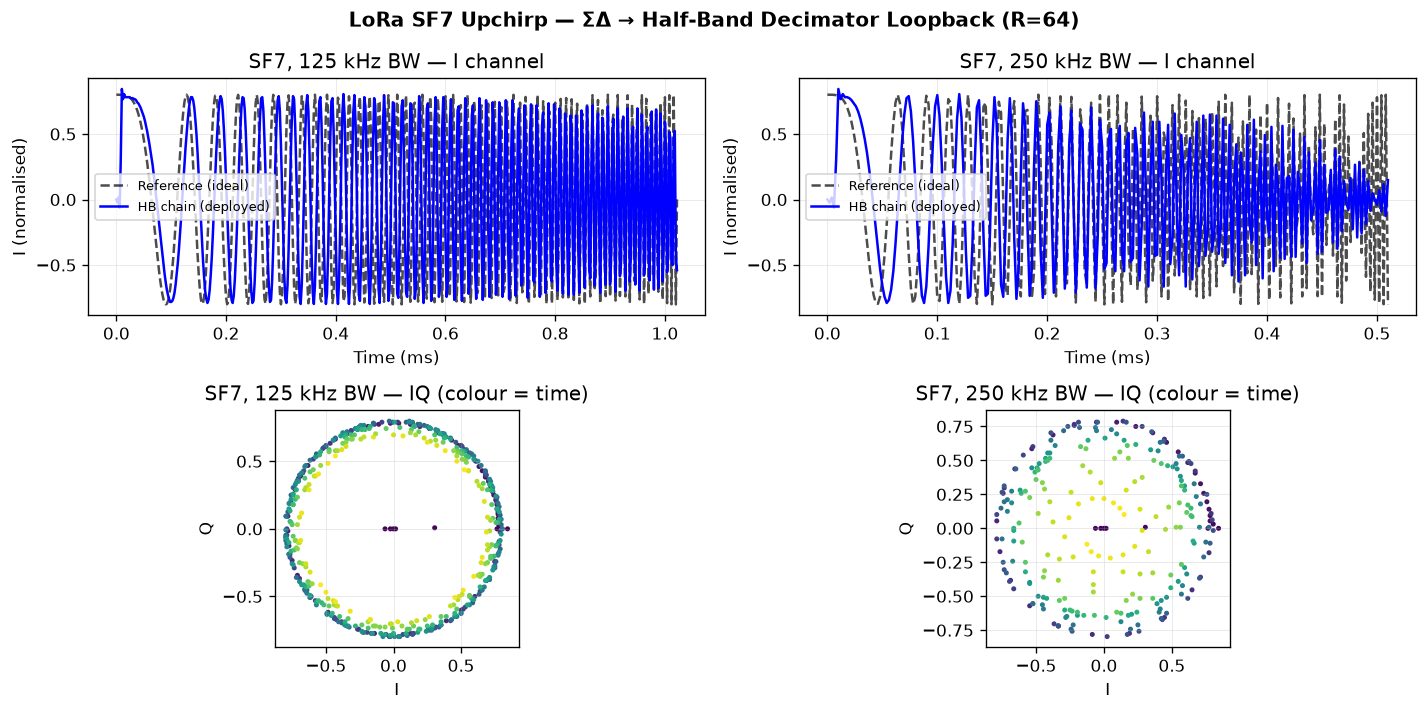

Saved: sim/plots/sd_decimator_loopback.png


In [20]:
SF = 7

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for col, bw in enumerate(SUPPORTED_BW):
    dec = SigmaDeltaDecimator(bw_hz=bw)
    M = dec.samples_per_symbol(SF)

    chirp_bb = modulate_oversampled(0, SF, 2 ** dec.sample_shift)  # correctly BW-limited
    chirp_hi = np.repeat(chirp_bb, DECIMATION_RATIO) / np.abs(chirp_bb).max()  # upsample to 32 MS/s

    amp = 0.8
    bits_i = sigma_delta_1st_order(amp * chirp_hi.real)
    bits_q = sigma_delta_1st_order(amp * chirp_hi.imag)
    bits = bits_i + 1j * bits_q

    out = dec.process(bits)

    t_bb = np.arange(M) / dec.fs_out * 1e3   # ms
    t_out = np.arange(len(out)) / dec.fs_out * 1e3

    ax = axes[0, col]
    ax.plot(t_bb, chirp_bb.real * amp, 'k--', lw=1.5, label='Reference (ideal)', alpha=0.7)
    ax.plot(t_out[:M], out.real[:M], 'b-', lw=1.5, label='HB chain (deployed)')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('I (normalised)')
    ax.set_title(f'SF{SF}, {bw/1e3:.0f} kHz BW — I channel')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    n_plot = M
    c = plt.cm.viridis(np.linspace(0, 1, n_plot))
    ax.scatter(out.real[:n_plot], out.imag[:n_plot], c=c, s=4)
    ax.set_xlabel('I'); ax.set_ylabel('Q')
    ax.set_title(f'SF{SF}, {bw/1e3:.0f} kHz BW — IQ (colour = time)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'LoRa SF{SF} Upchirp — ΣΔ → Half-Band Decimator Loopback (R={DECIMATION_RATIO})', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/sd_decimator_loopback.png', bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_decimator_loopback.png')

---
## 9  Feasibility: How Much Order Would 1x Oversampling Cost?

Section 8's discussion established that dropping to 1x oversampling for
250 kHz BW (`fs_out = BW = 250 kS/s`) puts the chirp edge exactly at the new
output Nyquist, with zero transition-band margin left for the anti-alias
filter. This section quantifies *how much filter order that actually costs*,
rather than just asserting it's bad.

**Setup:** model the final decimation stage as a generic decimate-by-2 FIR
(the same role HB2 plays today) running at `fs_in = 2 * fs_out`, with:
- passband edge `f_pass = BW/2 = 125 kHz` (fixed — this is the LoRa chirp edge, independent of OS)
- stopband edge `f_stop = fs_out - f_pass` (where the decimation image would fold back onto the passband edge)
- transition width `Δf = f_stop - f_pass = fs_out - BW = BW * (OS - 1)`

As `OS -> 1`, `Δf -> 0` and the required filter order diverges — there is
**no finite-order linear-phase FIR** that gives a sharp transition with zero
width. We use the standard Harris/Fred-harris equiripple order estimate,
`N ≈ (A_dB − 7.95) / (14.36 · Δf/fs_in)`, to quantify the divergence, then
verify a few feasible points with an actual `scipy.signal.remez` design.

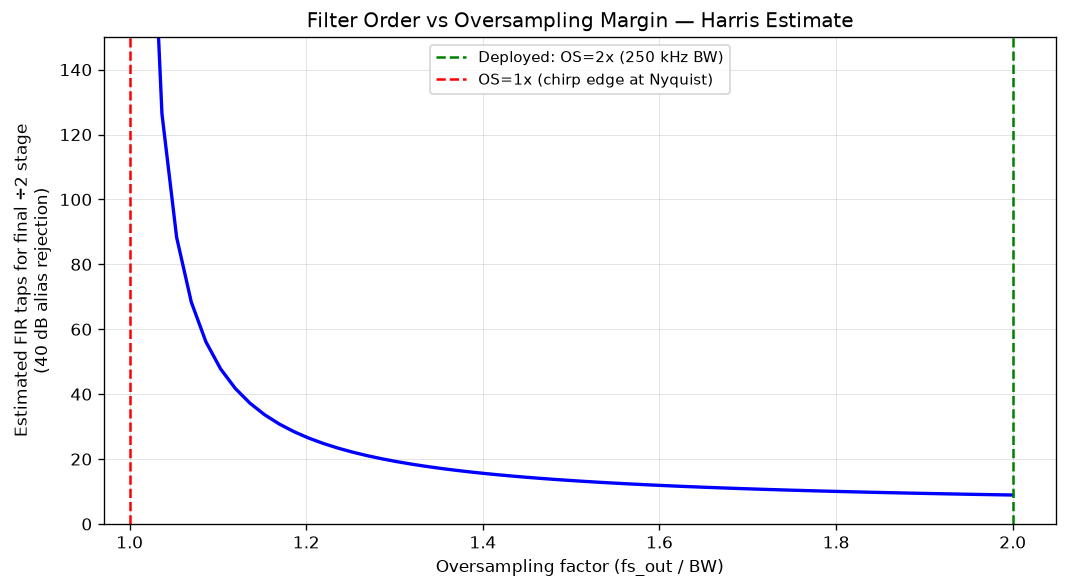

OS=1.05x  fs_out= 262.5 kHz  Δf=  12.5 kHz  estimated taps ≈   93.7
OS=1.10x  fs_out= 275.0 kHz  Δf=  25.0 kHz  estimated taps ≈   49.1
OS=1.25x  fs_out= 312.5 kHz  Δf=  62.5 kHz  estimated taps ≈   22.3
OS=1.50x  fs_out= 375.0 kHz  Δf= 125.0 kHz  estimated taps ≈   13.4
OS=2.00x  fs_out= 500.0 kHz  Δf= 250.0 kHz  estimated taps ≈    8.9

Deployed HB2 is 15 taps at OS=2x -- matches the ballpark above.
OS=1x (Δf=0) requires infinite order: no finite FIR can do it.


In [21]:
def harris_order_estimate(a_stop_db: float, delta_f_hz: float, fs_hz: float) -> float:
    """Fred Harris' equiripple FIR order approximation (taps, not including +1)."""
    if delta_f_hz <= 0:
        return float('inf')
    return (a_stop_db - 7.95) / (14.36 * (delta_f_hz / fs_hz))


BW = 250e3          # LoRa BW under test (fixed)
A_STOP_DB = 40.0     # target alias rejection, matching Gate 1's SQNR>=40dB accept threshold

os_sweep = np.linspace(1.02, 2.0, 60)   # OS=1.0 exactly is a pole (Δf=0); start just above it
orders = []
for os in os_sweep:
    fs_out = os * BW
    fs_in = 2 * fs_out           # this stage decimates by 2, same role as HB2 today
    f_pass = BW / 2
    f_stop = fs_out - f_pass
    delta_f = f_stop - f_pass
    orders.append(harris_order_estimate(A_STOP_DB, delta_f, fs_in))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(os_sweep, orders, 'b-', lw=2)
ax.axvline(2.0, color='g', ls='--', lw=1.5, label='Deployed: OS=2x (250 kHz BW)')
ax.axvline(1.0, color='r', ls='--', lw=1.5, label='OS=1x (chirp edge at Nyquist)')
ax.set_xlabel('Oversampling factor (fs_out / BW)')
ax.set_ylabel('Estimated FIR taps for final ÷2 stage\n(40 dB alias rejection)')
ax.set_title('Filter Order vs Oversampling Margin — Harris Estimate')
ax.set_ylim(0, 150)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/sd_decimator_os_feasibility.png', bbox_inches='tight')
plt.show()

for os in [1.05, 1.1, 1.25, 1.5, 2.0]:
    fs_out = os * BW
    fs_in = 2 * fs_out
    delta_f = fs_out - BW
    n = harris_order_estimate(A_STOP_DB, delta_f, fs_in)
    print(f'OS={os:.2f}x  fs_out={fs_out/1e3:>6.1f} kHz  Δf={delta_f/1e3:>6.1f} kHz  '
          f'estimated taps ≈ {n:>6.1f}')
print()
print('Deployed HB2 is 15 taps at OS=2x -- matches the ballpark above.')
print('OS=1x (Δf=0) requires infinite order: no finite FIR can do it.')

---
### Verify with an actual equiripple design

Design real filters with `scipy.signal.remez` at a few of the OS points
above (rounded to odd tap counts) and measure the actual passband droop at
the 125 kHz chirp edge and the stopband rejection at the image frequency, to
confirm the Harris estimate tracks a real filter.

In [22]:
from scipy.signal import remez, freqz

def design_and_measure(os: float, numtaps: int):
    fs_out = os * BW
    fs_in = 2 * fs_out
    f_pass = BW / 2
    f_stop = fs_out - f_pass
    if f_stop <= f_pass or f_stop >= fs_in / 2:
        return None  # infeasible band edges for this OS/tap combo

    taps = remez(numtaps, [0, f_pass, f_stop, fs_in / 2], [1, 0], fs=fs_in)
    w, h = freqz(taps, worN=8192, fs=fs_in)

    idx_pass = np.argmin(np.abs(w - f_pass))
    idx_stop = np.argmin(np.abs(w - f_stop))
    droop_db = 20 * np.log10(np.abs(h[idx_pass]))
    stop_atten_db = 20 * np.log10(np.max(np.abs(h[w >= f_stop])))
    return droop_db, stop_atten_db


print(f'{"OS":>6}  {"taps":>5}  {"droop@edge":>11}  {"worst stopband":>15}')
print('-' * 45)
for os, ntaps in [(1.1, 65), (1.25, 25), (1.5, 15), (2.0, 9)]:
    result = design_and_measure(os, ntaps)
    if result is None:
        print(f'{os:>5.2f}x  {ntaps:>5}  infeasible band edges')
        continue
    droop_db, stop_atten_db = result
    print(f'{os:>5.2f}x  {ntaps:>5}  {droop_db:>9.2f} dB  {stop_atten_db:>13.1f} dB')

print()
print('Takeaway: hitting ~40 dB alias rejection with low droop at the chirp edge')
print('costs single-digit taps at OS=2x (matches deployed HB2 = 15 taps) but climbs')
print('sharply as OS -> 1x -- confirming 1x oversampling is impractical for this')
print('architecture, not just "not currently implemented".')

    OS   taps   droop@edge   worst stopband
---------------------------------------------
 1.10x     65      -0.02 dB          -53.7 dB
 1.25x     25      -0.05 dB          -45.1 dB
 1.50x     15      -0.03 dB          -49.0 dB
 2.00x      9      -0.10 dB          -39.1 dB

Takeaway: hitting ~40 dB alias rejection with low droop at the chirp edge
costs single-digit taps at OS=2x (matches deployed HB2 = 15 taps) but climbs
sharply as OS -> 1x -- confirming 1x oversampling is impractical for this
architecture, not just "not currently implemented".


---
## Summary

| Item | Value |
|---|---|
| Deployed config | Half-band chain: CIC-3 R=16 → HB1 ÷2 → HB2 ÷2 |
| R (fixed) | 64 |
| fs_out | 500 kS/s |
| Supported LoRa BWs | 125 kHz (sample_shift=2, 4x OS) and 250 kHz (sample_shift=1, 2x OS) |
| BW select | Register 0x0A `BW_CFG.bw_sel`; selects `sample_shift`, not R |
| Symbol length | `M = 1 << (SF + sample_shift)` |
| 250 kHz chirp-edge droop | CIC-16 stage: ~-0.17 dB; full cascade: ~-0.4 dB (was -11.8 dB on the retired R=128 CIC-only chain) |
| Gate 1 SQNR (RTL, worst tested) | ~42 dB, ~-0.5 dB gain error at 125 kHz; full spectral sweep pending |
| 1x oversampling (250 kHz BW) | Infeasible — Section 9: required final-stage FIR order diverges as OS->1 (zero transition-band margin) |
| 1 MS/s output | Out of scope — PSRAM timing budget exceeded |
| Reference | `planning/decimator-hb-migration-impact-plan.md` (Gates 0-12) |